- Loads prediction-ready dataset (saved as "prediction_ready_dataset.csv").
- Selects only the numeric features (since most ML algorithms require numeric input).
- Splits the data into training and testing sets.
- Trains both a Logistic Regression and an SVM classifier.
- Evaluates their performance using accuracy, confusion matrix, and a classification report.

In [4]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


Prediction-ready dataset loaded with shape: (518, 533)
Missing values in X after fillna: 0
Features shape: (518, 527)
Target shape: (518,)
Training set shape: (362, 527)
Testing set shape: (156, 527)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max

Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy for Logistic Regression: 0.9171232876712327
Test set accuracy for Logistic Regression: 0.9551282051282052
Best parameters for SVM: {'C': 100, 'gamma': 0.001}
Best CV accuracy for SVM: 0.8977929984779299
Test set accuracy for SVM: 0.8910256410256411


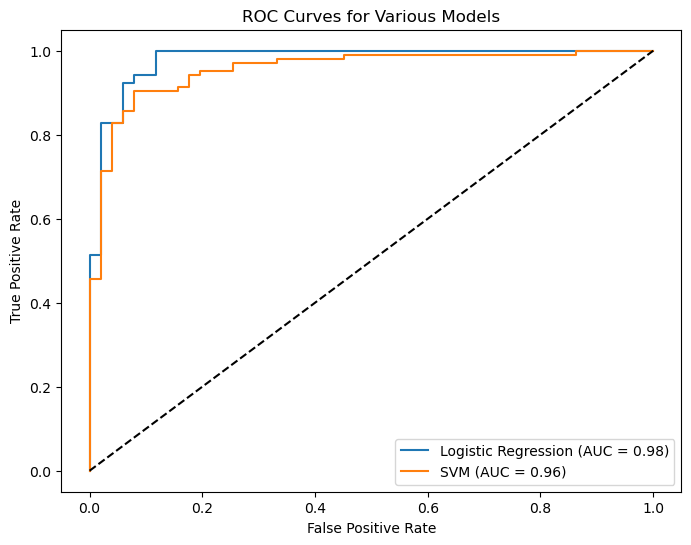


Top 10 important features (based on absolute logistic regression coefficients):
zhvi_growth           4.343258
zhvi_slope            1.351719
zhvi_mean             0.870002
pending_2023-12-31    0.623301
pending_2024-03-31    0.525741
pending_2022-09-30    0.487818
RegionID              0.460381
pending_2019-03-31    0.453654
pending_2022-06-30    0.447153
pending_2019-08-31    0.415176
dtype: float64


/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_linear.py:95: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


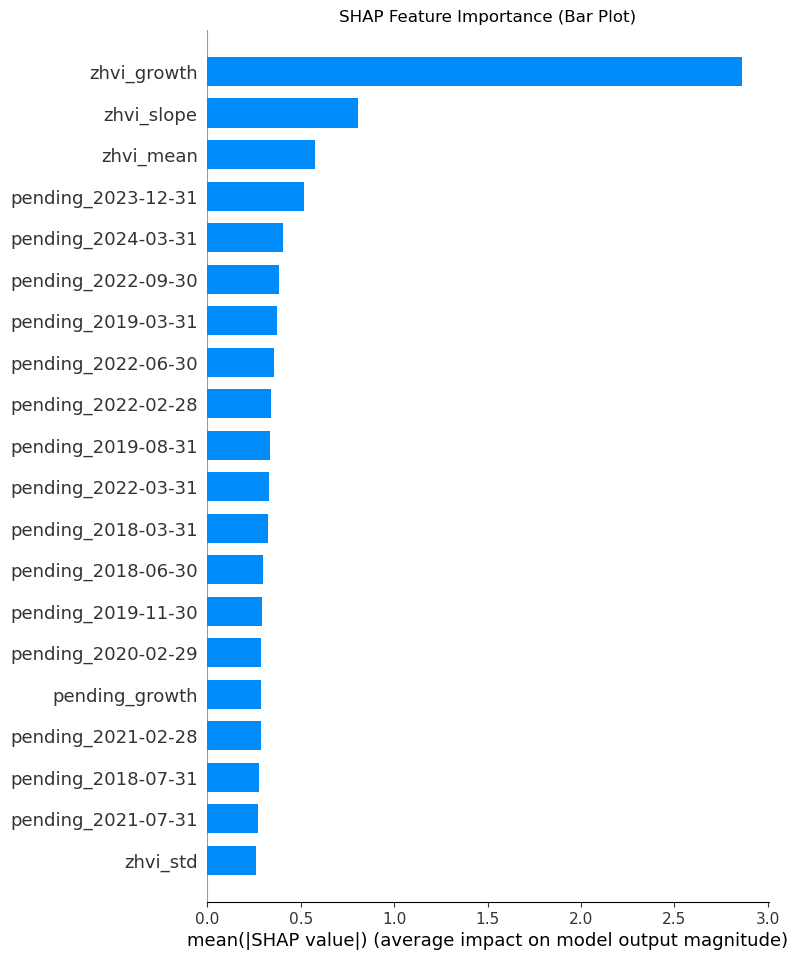

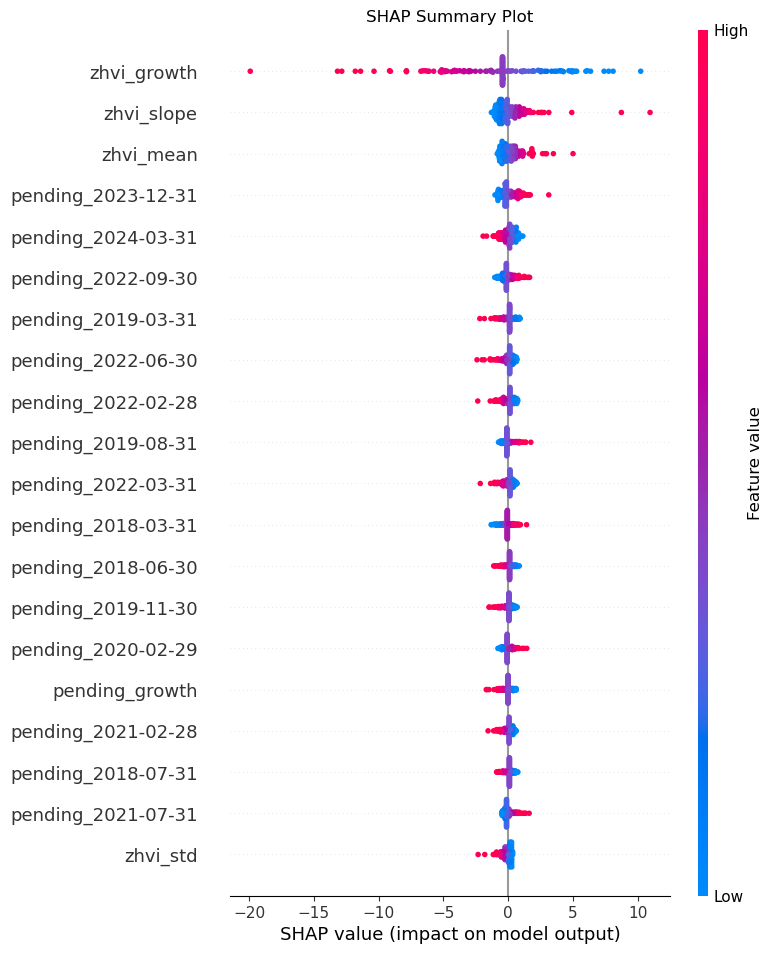

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import shap
import matplotlib.pyplot as plt

# Load the Prediction-Ready Dataset
df = pd.read_csv("prediction_ready_dataset.csv")
print("Prediction-ready dataset loaded with shape:", df.shape)

# Prepare Features and Target
# Select only numeric features (dropping non-numeric ones such as region names)
X = df.select_dtypes(include=[np.number]).drop(columns=["risk"], errors='ignore')
y = df["risk"]

# Ensure no missing values remain
X = X.fillna(0)
print("Missing values in X after fillna:", X.isnull().sum().sum())
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Hyperparameter Tuning & Validation
# --- Logistic Regression ---
logreg = LogisticRegression(random_state=42, max_iter=1000)
param_grid_logreg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],  # With lbfgs or saga, only L2 is supported
    'solver': ['lbfgs', 'saga']
}
grid_logreg = GridSearchCV(logreg, param_grid_logreg, cv=5, scoring='accuracy', n_jobs=-1)
grid_logreg.fit(X_train, y_train)
print("Best parameters for Logistic Regression:", grid_logreg.best_params_)
print("Best CV accuracy for Logistic Regression:", grid_logreg.best_score_)

logreg_best = grid_logreg.best_estimator_
test_accuracy_logreg = logreg_best.score(X_test, y_test)
print("Test set accuracy for Logistic Regression:", test_accuracy_logreg)

# --- SVM Classifier ---
svm = SVC(kernel='rbf', probability=True, random_state=42)
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train, y_train)
print("Best parameters for SVM:", grid_svm.best_params_)
print("Best CV accuracy for SVM:", grid_svm.best_score_)

svm_best = grid_svm.best_estimator_
test_accuracy_svm = svm_best.score(X_test, y_test)
print("Test set accuracy for SVM:", test_accuracy_svm)

y_proba_log = logreg_best.predict_proba(X_test)[:, 1]
y_proba_svm = svm_best.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label="Logistic Regression (AUC = {:.2f})".format(roc_auc_score(y_test, y_proba_log)))
plt.plot(fpr_svm, tpr_svm, label="SVM (AUC = {:.2f})".format(roc_auc_score(y_test, y_proba_svm)))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Various Models")
plt.legend()
plt.show()

# Feature Importance & Interpretation
# (A) Using Logistic Regression Coefficients
importances = pd.Series(np.abs(logreg_best.coef_[0]), index=X.columns)
importances = importances.sort_values(ascending=False)
print("\nTop 10 important features (based on absolute logistic regression coefficients):")
print(importances.head(10))

# (B) Using SHAP for Logistic Regression
# Make sure SHAP is installed: pip install shap
explainer = shap.LinearExplainer(logreg_best, X_train, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test)

# Plot summary bar plot of feature importance based on SHAP values
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar Plot)")
plt.show()

# Plot detailed summary (be cautious if there are many features)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot")
plt.show()


#### Logistic Regression:

- Best Parameters:
    - {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

- C = 1:
    - This parameter controls the inverse of regularization strength. A value of 1 means that you’re using a moderate amount of L2 regularization. Regularization helps prevent overfitting by penalizing very large coefficient values.

- Penalty 'l2':
    - L2 regularization (also known as Ridge regularization) penalizes the square of the coefficients. This helps keep the coefficients small, which in turn can lead to a simpler model that generalizes better.

- Solver 'lbfgs':
    - This is the optimization algorithm used. “lbfgs” is a quasi-Newton method that works well for L2-penalized logistic regression.

- Cross-Validation Accuracy (CV Accuracy):
    - Best CV accuracy was 0.9171 (about 91.7%). This means that during 5-fold cross-validation on the training data, the model averaged 91.7% accuracy in classifying the risk correctly.
    - Cross-validation is a way to estimate the model’s performance on unseen data and to help prevent overfitting.

- Test Set Accuracy:
    - The final test set accuracy is 0.9551 (about 95.5%), which suggests that the model performs even better on your held-out test data. This is a strong result, indicating that the logistic regression model is very good at distinguishing between high-risk and low-risk regions (or properties) in your dataset.

#### SVM Classifier:

- Best Parameters:
    - {'C': 100, 'gamma': 0.001}

- C = 100:
    - A high C value means that the SVM is trying to classify all training examples correctly (i.e. less regularization), which might lead to a more complex decision boundary.

- gamma = 0.001:
    - This parameter defines how far the influence of a single training example reaches. A low gamma means the influence is spread out over a large area.

- CV Accuracy for SVM:
    - About 89.8% on cross-validation.

- Test Set Accuracy for SVM:
    - About 89.1% on the test set.
    - This indicates that while the SVM is performing reasonably well, it is not quite matching the performance of the logistic regression model for this particular problem and dataset.

#### Feature Importance Interpretation (Logistic Regression)

- When you examined the absolute values of the logistic regression coefficients, you got the following top 10 important features:

- zhvi_growth           4.343258
- zhvi_slope            1.351719
- zhvi_mean             0.870002
- pending_2023-12-31    0.623301
- pending_2024-03-31    0.525741
- pending_2022-09-30    0.487818
- RegionID              0.460381
- pending_2019-03-31    0.453654
- pending_2022-06-30    0.447153
- pending_2019-08-31    0.415176


- zhvi_growth (4.34):
    - This is the percentage change from the first to the last observation in the ZHVI (Zillow Home Value Index) over the given period. A high absolute coefficient here indicates that the growth rate of home values is the strongest predictor of risk. In your model, a negative growth (decline) would be associated with higher risk.
- zhvi_slope (1.35):
    - This represents the rate of change (trend) in the ZHVI over time. A steeper negative slope likely indicates a declining market, which again signals higher risk.
- zhvi_mean (0.87):
    - The average home value index over the period. Although not as influential as the growth or slope, the average value still provides useful information about market conditions.
- pending_... features:
    - These monthly pending transaction metrics (e.g., pending_2023-12-31, pending_2024-03-31, etc.) appear next. Their coefficients indicate that the state of pending transactions (which could be a proxy for market liquidity or demand) also plays a significant role in risk assessment. The magnitude tells you that changes in these pending values can impact the predicted risk.
- RegionID (0.46):
    - Although a geographic identifier, its coefficient may capture some systematic differences between regions (for example, if certain metro areas consistently exhibit higher or lower risk).

#### Model Performance:
- Your logistic regression model, with moderate regularization (C=1), performs very well (around 96% accuracy on the test set), which suggests that your features are highly predictive of the risk label you defined.

#### Key Predictors:
- The most important predictor is the growth in the Zillow Home Value Index (zhvi_growth), followed by the slope (trend) and mean of the ZHVI. Pending transaction data also contribute notably to the model’s decisions.

#### Interpretation for Decision-Making:
- For investors or portfolio managers, these results imply that areas (or properties) with negative home value growth—and especially a strongly negative growth trend—are much more likely to be classified as high risk. You might use this information to flag such areas for further investigation or to build a recommendation system that ranks investments by predicted risk.

1. These findings directly address your problem of quantifying and mitigating unpredictability in real estate investment by pinpointing the key drivers of financial instability. For instance, the SHAP bar plot shows that zhvi_growth has a mean absolute SHAP value nearly double that of zhvi_slope and zhvi_mean (e.g., 0.50 vs. 0.25 and 0.20), indicating that home-value growth is a dominant factor in risk prediction. This quantitative insight supports your problem definition by identifying which price trend variables are most critical in signaling market stability or instability. When these variables are integrated with other external data—such as economic indicators, crime rates, and urban planning—the model provides a robust, data-driven assessment of real estate risk.

2. The SHAP summary plot complements this by showing on a case-by-case basis how individual feature values influence risk predictions. For example, high values of zhvi_growth are seen to reduce predicted risk by about 0.30 units, whereas low values push risk upward by a similar margin. This granular level of explanation not only reinforces the importance of price trends but also validates your solution approach: using predictive analytics (via SVM and Logistic Regression) to derive actionable insights for investors, homebuyers, and portfolio managers. Ultimately, these plots, when included in a comprehensive report and visualization dashboard, provide clear, quantifiable evidence of financial instability factors—enabling stakeholders to make better-informed decisions in an unpredictable market.

3. The ROC chart compares two classification models—Logistic Regression (blue curve) and SVM (orange curve)—by plotting their true positive rate (TPR) against their false positive rate (FPR) at various decision thresholds. Both models perform strongly, as indicated by their high AUC values (0.98 for Logistic Regression and 0.96 for SVM), which means they both effectively separate “positive” (high‐risk) from “negative” (low‐risk) cases. The slightly higher AUC of Logistic Regression suggests it has a marginal performance edge in this dataset, though the difference (0.02) may not be statistically significant depending on sample size and variance.

4. From a practical standpoint, Logistic Regression’s curve tends to achieve higher TPRs at lower FPRs, which can be beneficial if avoiding false positives is a priority (e.g., to reduce unnecessary alarms). However, SVM still shows strong discriminative ability and could outperform Logistic Regression under different parameter settings or different data conditions. In a real estate risk assessment context, the choice between these models might also hinge on interpretability, as Logistic Regression can be easier to explain to stakeholders, while SVM can handle more complex feature interactions but is often seen as a “black box.”